# Script to test and tune cell segmentation parameters

In [2]:
import sys
import json
import argparse
import numpy  as np
import pandas as pd
import trackpy as tp
import matplotlib.pyplot as plt

from tqdm     import tqdm
from pathlib  import Path
from datetime import datetime
from skimage.measure import regionprops
from skimage.feature import peak_local_max

sys.path.append("scripts/utils/")
from file_operations import *
from segmentation    import *
from Microscopes     import Holomonitor, Tomocube
from SegmentedCells  import SegmentedCells

data_path = "../../../../hdd_data/silja/Monolayers/"

In [3]:
dataset = "MDCK_20240516_B1-9"
config  = json.load(open(f"configs/{dataset}.json"))

p0   = config['detection']['particle_size']
tau  = config['detection']['tau']
fmin = config['field']['fmin']
fmax = config['field']['fmax']
Nframes = fmax - fmin + 1

if config['boundary'] == "open":
    clear_edge = True
else:
    clear_edge = False


### SET MICROSCOPE ###
if config['microscope'] == "holomonitor": microscope = Holomonitor()
elif config['microscope'] == "tomocube":  microscope = Tomocube()

In [4]:
frame = fmin #+ 20
h_im, n_im = load_set_of_frames(f"{data_path}height_fields/raw/{dataset}", frame, microscope)

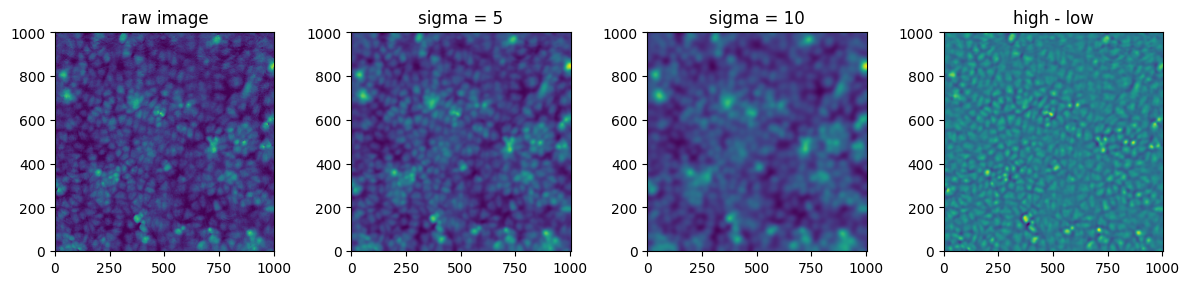

In [23]:
# Smoothen field
n_norm = smoothen_normalize_im(n_im, config['detection']['s_high']-1, 
                                     config['detection']['s_low']-2, fig=True)

In [24]:
# Find peaks
# Estimating average particle size from cell doubling time
p_size   = np.round(p0 * 2 ** (-(frame-fmin) / (2*tau / microscope.frame_to_h)))
full_pos = np.array(peak_local_max(n_norm, min_distance=int(p_size)))


# Remove non-confluent areas
pos = full_pos[(full_pos[:,1] > config['segmentation']['xmin']) * (full_pos[:,1] < config['segmentation']['xmax'])]
pos =      pos[(     pos[:,0] > config['segmentation']['ymin']) * (     pos[:,0] < config['segmentation']['ymax'])]


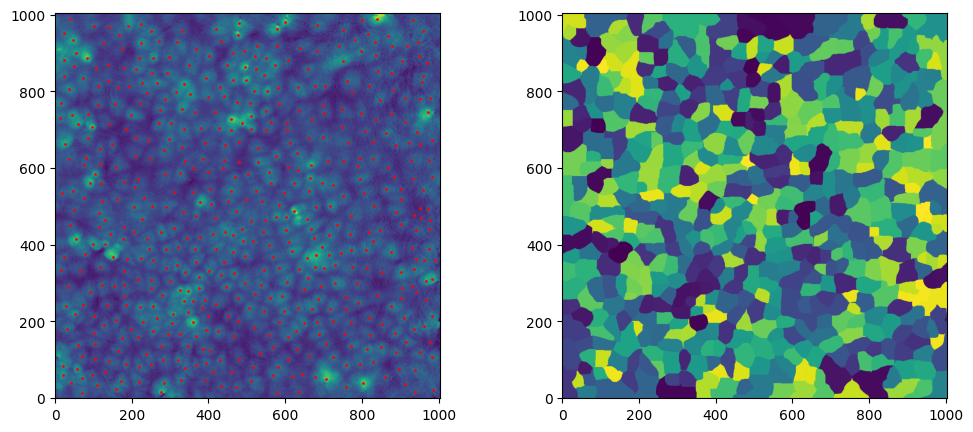

In [25]:
raw_areas = get_cell_areas(-n_norm, pos, h_im, clear_edge=False)

plt.figure(figsize=(12,5))
plt.subplot(121)
plt.imshow(h_im, origin="lower")
plt.plot(pos[:,1], pos[:,0], 'r.', ms=2)

plt.subplot(122)
plt.imshow(raw_areas, origin="lower")

501


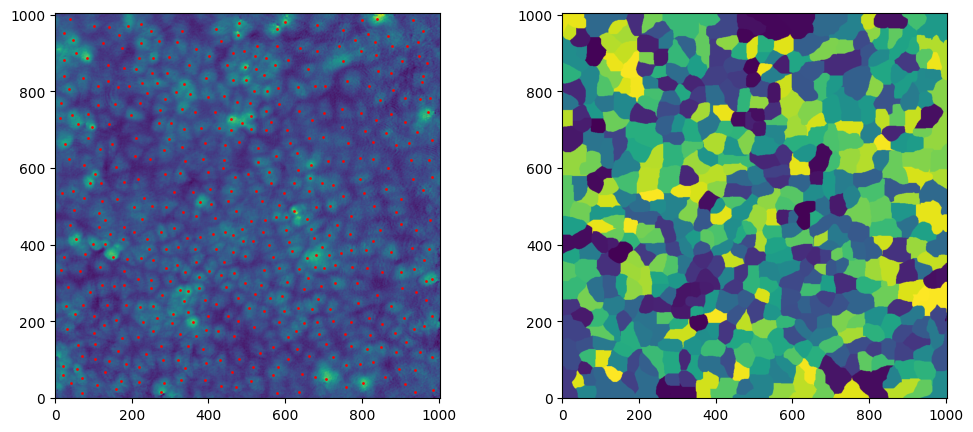

In [26]:
# Get cell properties
cell_props     = regionprops(raw_areas, h_im)
cell_areas     = np.array([cell.area for cell in cell_props])
cell_heights   = np.array([cell.mean_intensity for cell in cell_props])
cell_volumes   = cell_areas * cell_heights 
cell_positions = np.array([cell.centroid for cell in cell_props], dtype=int)

# create mask to remove small cells
remove_small  = (cell_heights > config['filtering']['hmin'])
remove_small *= (cell_areas   > config['filtering']['Amin'] / microscope.pix_to_um**2) 
remove_small *= (cell_volumes > config['filtering']['Vmin'] / microscope.pix_to_um**2)

pos   = pos[remove_small]
areas = get_cell_areas(-n_norm, pos, h_im, clear_edge=False)


plt.figure(figsize=(12,5))
plt.subplot(121)
plt.imshow(h_im, origin="lower")
plt.plot(pos[:,1], pos[:,0], 'r.', ms=2)

plt.subplot(122)
plt.imshow(areas, origin="lower")

print(len(pos))

In [28]:
# Compute region props of cells in all frames
cellprops = regionprops(areas, h_im)

A = np.array([cell.area           for cell in cellprops])* microscope.pix_to_um**2
h = np.array([cell.mean_intensity for cell in cellprops])
V = h*A

In [29]:
# Filter out based on cell size
remove_small = (h > config["filtering"]["hmin"]) * (A > config["filtering"]["Amin"]) * (h * A > config["filtering"]["Vmin"])
remove_large = (h < config["filtering"]["hmax"]) * (A < config["filtering"]["Amax"]) * (h * A < config["filtering"]["Vmax"])

mask =  remove_small * remove_large

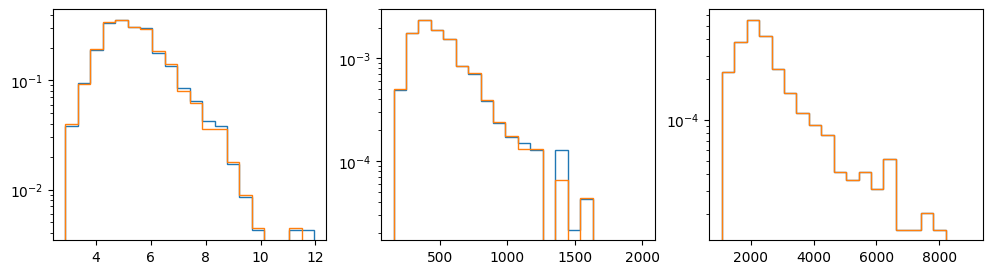

In [30]:
fig, ax = plt.subplots(1, 3, figsize=(12,3))

ax[0].hist(h.ravel(), bins=20, density="true", range=[h.min(), h.max()], histtype="step")
ax[1].hist(A.ravel(), bins=20, density="true", range=[A.min(), 2000], histtype="step")
ax[2].hist(V.ravel(), bins=20, density="true", range=[V.min(), 9000], histtype="step")

ax[0].hist(h[mask].ravel(), bins=20, density="true", range=[h.min(), h.max()], histtype="step")
ax[1].hist(A[mask].ravel(), bins=20, density="true", range=[A.min(), 2000], histtype="step")
ax[2].hist(V[mask].ravel(), bins=20, density="true", range=[V.min(), 9000], histtype="step")

for axis in ax:
    axis.set(yscale="log")